<a href="https://colab.research.google.com/github/Adiel13/Proyecto_grupo3/blob/master/Atividade_1_Fundamentos_Matem%C3%A1ticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INTRODUÇÃO**

O presente trabalho tem como objetivo modelar a distribuição de temperatura em uma barra metálica ao longo do tempo, utilizando a equação do calor e sua representação por séries de Fourier.

A partir de uma condição inicial de temperatura uniforme e considerando condições de contorno específicas, busca-se descrever matematicamente a evolução térmica do sistema, bem como analisar seu comportamento ao longo do tempo por meio de simulações numéricas e representações gráficas.

A implementação foi realizada em Python, no ambiente Google Colab, o que permitiu validar os resultados e visualizar a dinâmica de resfriamento da barra.



**BIBLIOTECAS UTILIZADAS**

Para a implementação computacional, foram utilizadas bibliotecas voltadas ao cálculo numérico, integração e visualização gráfica.

In [ ]:
from scipy.integrate import quad as integral  # função para integração numérica
from math import *
import numpy as np
import matplotlib.pyplot as plt

**FORMULAÇÃO DO PROBLEMA**

Considere uma barra metálica unidimensional de comprimento L = 50 cm, inicialmente em equilíbrio térmico, com temperatura uniforme igual a T = 100 em toda a sua extensão.

A partir do instante inicial, as extremidades da barra são mantidas a temperatura zero, estabelecendo as seguintes condições de contorno:

$u(0,t) = 0$

$u(L,t) = 0$

Despreza-se o efeito das dimensões laterais (altura e largura), assumindo um modelo unidimensional.

O objetivo é determinar a função $u(x,t)$ que descreve a distribuição de temperatura ao longo da barra em função da posição e do tempo, utilizando a equação do calor e sua solução por meio de séries de Fourier.

In [ ]:
# constantes da condição de fronteira
L = 50
T = 100

**FUNÇÃO INTEGRANDO**


Define-se a função integrando como base para o cálculo dos coeficientes da série de Fourier.

In [ ]:
def integrando(x, n):
    return T * sin(n * pi * x / L)

Definimos a função F(n) como a integral do integrando no intervalo de 0 a L.

In [ ]:
def F(n):
    return integral(lambda x: integrando(x, n), 0, L)[0]

**CONSTRUÇÃO DO SOMATÓRIO**


A solução da equação do calor é representada como uma soma de termos da série de Fourier. Para fins computacionais, o somatório infinito é aproximado por um número finito de termos.

In [ ]:
def somatorio(f, a, N=50):
    soma = 0
    for n in range(a, N+1):
        soma += f(n)
    return soma


**DEFINIÇÃO DA FUNÇÃO u(x,t)**

A função $u(x,t)$ representa a distribuição de temperatura ao longo da barra e é construída a partir dos coeficientes de Fourier e de sua evolução no tempo.

In [ ]:
def u(x, t):
    return 2/L * somatorio(
        lambda n: F(n) * sin((n * pi / L) * x) * e**(-(n * pi / L)**2 * t),
        1
    )

**VALIDAÇÃO DA FUNÇÃO**

A função $u(x,t)$ é avaliada em um ponto específico com o objetivo de verificar seu comportamento em relação à condição inicial do problema.

In [ ]:
u(25, 0)

101.27273126258306

**ANÁLISE GRÁFICA**


Apresenta-se a evolução da distribuição de temperatura ao longo da barra para diferentes instantes de tempo, o que permite observar o processo de resfriamento do sistema.

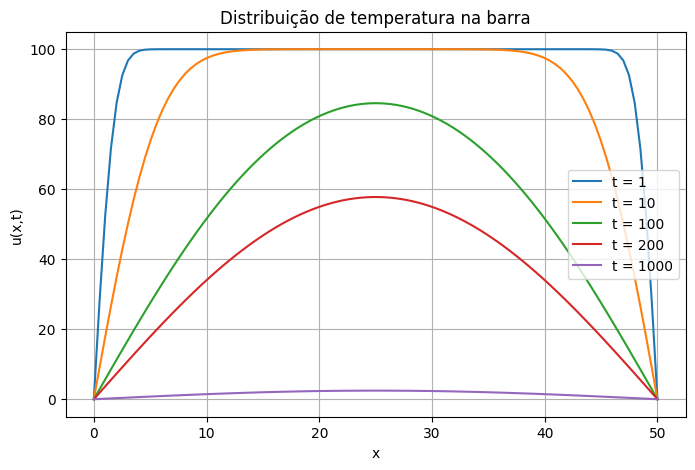

In [ ]:
# valores de x
x_vals = np.linspace(0, L, 100)

# tempos que queremos visualizar
tempos = [ 1, 10,100, 200,1000]

# plot
plt.figure(figsize=(8,5))

for t in tempos:
    y = [u(x, t) for x in x_vals]
    plt.plot(x_vals, y, label=f"t = {t}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Distribuição de temperatura na barra")
plt.legend()
plt.grid()

plt.show()